# PECD country-level check: onshore wind

PECD v4.2's `sis-energy-pecd` dataset on CDS offers a country-level
(`nuts_0`) capacity-factor product -- but only for solar. Confirmed
directly against the live CDS API: requesting
`wind_power_onshore_capacity_factor` at `spatial_resolution=nuts_0` is
rejected, and the API's own constraint solver drops wind's
capacity-factor variables from the allowed set entirely once `nuts_0` is
selected (wind is offered at zone level only -- `peon`/`peof`/`p2on`/
`p2of`/`szon`/`szof`). ECMWF's own 2025 ENTSO-E training material
confirms the `nuts_0` product itself is just "a naive spatial mean that
assumes [generation] is equally present within a given territory" -- no
capacity weighting, for the technologies it *does* cover.

`energy-data-hub`'s `pecd_wind_onshore_country_capacity_factor` asset
(`edh/pecd.py`'s `country_level_naive_mean`) replicates that exact
method on the zone data the hub already holds -- DE only, PEON zones,
technology 30 (already the hub's onshore-wind technology choice). This
page checks it against `de_capacity_factor_current_fleet`'s own
MaStR-capacity-weighted DE wind-onshore series: how close is PECD's own
(unweighted) method to what real turbine siting actually adds?

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from insights.paths import hub_file

NAIVE_COLOR = "#7a7a7a"  # PECD's own nuts_0 method -- unweighted, treated as the reference/baseline here
WEIGHTED_COLOR = "#2a78d6"  # this hub's MaStR-capacity-weighted series (same blue used for wind_onshore elsewhere in this book)

## Building the comparison panel

In [2]:
naive = pd.read_parquet(hub_file("pecd", "pecd_wind_onshore_country_capacity_factor.parquet")).iloc[:, 0].rename("naive")
weighted = pd.read_parquet(hub_file("pecd", "de_capacity_factor_current_fleet.parquet"))["capacity_factor_wind_onshore"].rename("weighted")

df = pd.concat([naive, weighted], axis=1, join="inner").dropna().sort_index()
print(f"Joined panel: {df.shape}, {df.index.min()} .. {df.index.max()}")

Joined panel: (96432, 2), 2015-01-01 00:00:00 .. 2025-12-31 23:00:00


## Headline comparison

In [3]:
def error_stats(frame: pd.DataFrame) -> dict:
    err = frame["naive"] - frame["weighted"]
    return {
        "n_hours": len(frame),
        "corr": frame["naive"].corr(frame["weighted"]),
        "bias_pp": err.mean() * 100,
        "mae_pp": err.abs().mean() * 100,
        "rmse_pp": (err**2).mean() ** 0.5 * 100,
    }


print(pd.Series(error_stats(df)).round(4))

n_hours    96432.0000
corr           0.9698
bias_pp        0.3505
mae_pp         3.4778
rmse_pp        4.8255
dtype: float64


## Monthly capacity factor, full history

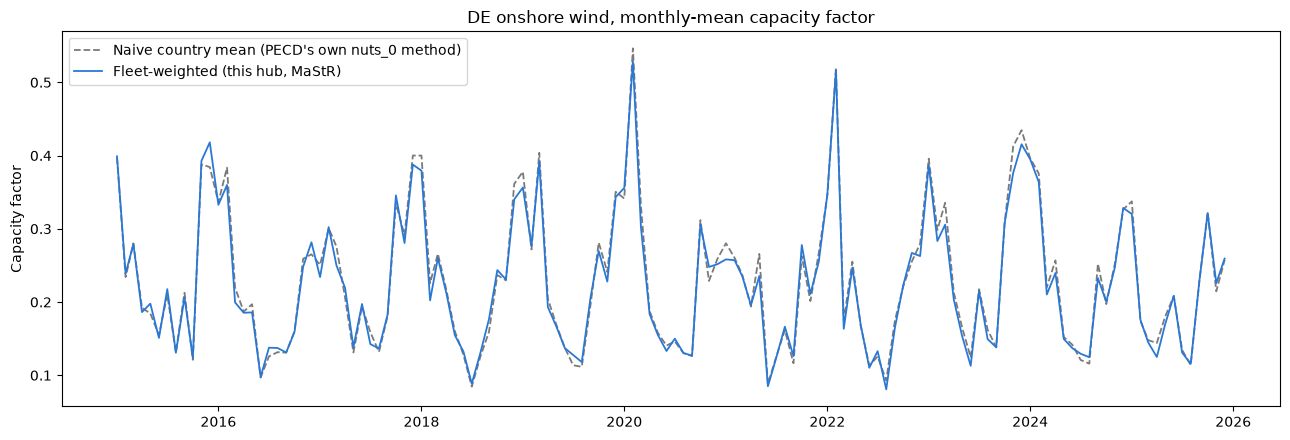

In [4]:
monthly = df.resample("MS").mean()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(monthly.index, monthly["naive"], label="Naive country mean (PECD's own nuts_0 method)", color=NAIVE_COLOR, linewidth=1.3, linestyle="--")
ax.plot(monthly.index, monthly["weighted"], label="Fleet-weighted (this hub, MaStR)", color=WEIGHTED_COLOR, linewidth=1.3)
ax.set_ylabel("Capacity factor")
ax.set_title("DE onshore wind, monthly-mean capacity factor")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

## Annual mean

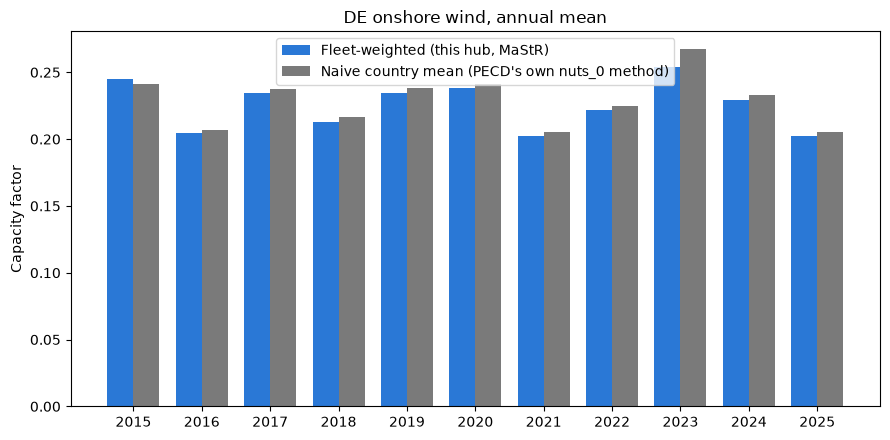

In [5]:
annual = df.groupby(df.index.year).mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(annual))
width = 0.38
ax.bar(x - width / 2, annual["weighted"], width, label="Fleet-weighted (this hub, MaStR)", color=WEIGHTED_COLOR)
ax.bar(x + width / 2, annual["naive"], width, label="Naive country mean (PECD's own nuts_0 method)", color=NAIVE_COLOR)
ax.set_xticks(x)
ax.set_xticklabels(annual.index)
ax.set_ylabel("Capacity factor")
ax.set_title("DE onshore wind, annual mean")
ax.legend()
fig.tight_layout()
plt.show()

## Daily means, paired

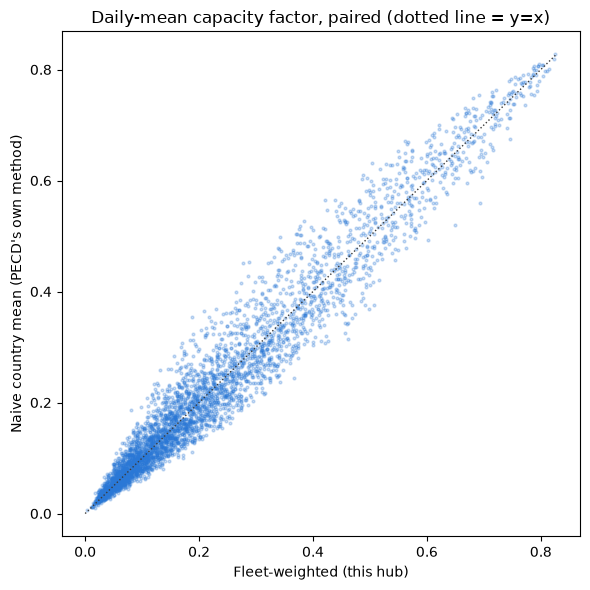

In [6]:
daily = df.resample("D").mean()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(daily["weighted"], daily["naive"], s=4, alpha=0.25, color=WEIGHTED_COLOR, rasterized=True)
lims = [0, max(daily["weighted"].max(), daily["naive"].max())]
ax.plot(lims, lims, color="#3a3a3a", linewidth=1, linestyle=":")
ax.set_xlabel("Fleet-weighted (this hub)")
ax.set_ylabel("Naive country mean (PECD's own method)")
ax.set_title("Daily-mean capacity factor, paired (dotted line = y=x)")
fig.tight_layout()
plt.show()

## Load duration curve

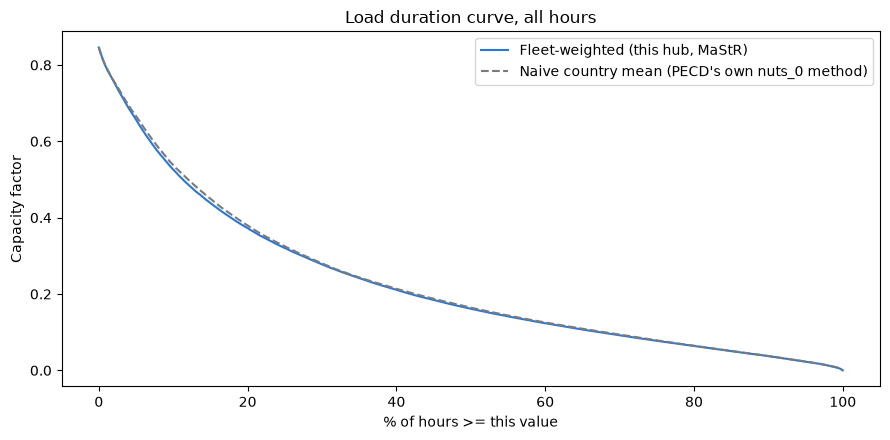

In [7]:
pct = np.linspace(0, 100, 251)
naive_sorted = np.percentile(df["naive"].to_numpy(), 100 - pct)
weighted_sorted = np.percentile(df["weighted"].to_numpy(), 100 - pct)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(pct, weighted_sorted, label="Fleet-weighted (this hub, MaStR)", color=WEIGHTED_COLOR, linewidth=1.5)
ax.plot(pct, naive_sorted, label="Naive country mean (PECD's own nuts_0 method)", color=NAIVE_COLOR, linewidth=1.5, linestyle="--")
ax.set_xlabel("% of hours >= this value")
ax.set_ylabel("Capacity factor")
ax.set_title("Load duration curve, all hours")
ax.legend()
fig.tight_layout()
plt.show()

## Takeaways

- Correlation is ~0.97 at hourly resolution -- both series are driven by
  the same underlying PECD zone-level weather data, so the shape agrees
  almost exactly; the gap between them is a *level* difference, not a
  *timing* one.
- Mean bias is small (~+0.3 percentage points, naive slightly higher)
  but not zero -- the naive spatial mean treats DE's 7 PEON zones as
  equally weighted, while MaStR's real turbine siting is not uniform
  across them.
- The gap is not perfectly constant year to year (see the annual-mean
  view) -- consistent with Germany's onshore wind buildout shifting
  which zones carry more installed capacity over time, something a
  naive equal-weighted mean can never capture by construction.
- This is the intended use of `pecd_wind_onshore_country_capacity_factor`:
  a PECD-native sanity check for `de_capacity_factor_current_fleet`, not
  a replacement for it -- the fleet-weighted series remains this hub's
  primary DE onshore-wind capacity-factor product.